# **IMPORTING LIBRARIES**


In [237]:
import pandas as pd;
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from termcolor import colored
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
warnings.filterwarnings('ignore')


# **IMPORTING DATA**

In [238]:
feed=pd.read_csv('/content/feed.csv')
print(feed.head())

   Unnamed: 0   X1                 date  % Iron Feed  % Silica Feed  \
0           1  0.0  2017-03-10 01:02:00         55.2          16.98   
1           2  1.0  2017-03-10 01:02:20         55.2          16.98   
2           3  2.0  2017-03-10 01:02:40         55.2          16.98   
3           4  3.0  2017-03-10 01:03:00         55.2          16.98   
4           5  4.0  2017-03-10 01:03:20         55.2          16.98   

   Starch Flow  Amina Flow  Ore Pulp Flow  Ore Pulp pH  Ore Pulp Density  \
0      3019.53     557.434        395.713      10.0664              1.74   
1      3024.41     563.965        397.383      10.0672              1.74   
2      3043.46     568.054        399.668      10.0680              1.74   
3      3047.36     568.665        397.939      10.0689              1.74   
4      3033.69     558.167        400.254      10.0697              1.74   

   % Iron Concentrate  % Silica Concentrate  
0           66.493242                  1.31  
1           66.853733   

In [239]:
flotation=pd.read_csv('/content/flotation.csv')
print(flotation.head())

   Unnamed: 0   X1                 date  Flotation Column 01 Air Flow  \
0           1  0.0  2017-03-10 01:02:00                       249.214   
1           2  1.0  2017-03-10 01:02:20                       249.719   
2           3  2.0  2017-03-10 01:02:40                       249.741   
3           4  3.0  2017-03-10 01:03:00                       249.917   
4           5  4.0  2017-03-10 01:03:20                       250.203   

   Flotation Column 02 Air Flow  Flotation Column 03 Air Flow  \
0                       253.235                       250.576   
1                       250.532                       250.862   
2                       247.874                       250.313   
3                       254.487                       250.049   
4                       252.136                       249.895   

   Flotation Column 04 Air Flow  Flotation Column 05 Air Flow  \
0                       295.096                         306.4   
1                       295.096         

In [240]:
merged_data = pd.merge(feed, flotation, on="date")
merged_data = merged_data.drop_duplicates()
merged_data.head(5)

,Unnamed: 0_x,X1_x,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,...,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level
0,1,0.0,2017-03-10 01:02:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,...,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344
1,2,1.0,2017-03-10 01:02:20,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,...,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075
2,3,2.0,2017-03-10 01:02:40,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,...,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567
3,4,3.0,2017-03-10 01:03:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,...,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669
4,5,4.0,2017-03-10 01:03:20,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,...,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679


# **EDA**

In [241]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589962 entries, 0 to 589961
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Unnamed: 0_x                  589962 non-null  int64  
 1   X1_x                          589962 non-null  float64
 2   date                          589962 non-null  object 
 3   % Iron Feed                   589962 non-null  float64
 4   % Silica Feed                 589962 non-null  float64
 5   Starch Flow                   589962 non-null  float64
 6   Amina Flow                    589962 non-null  float64
 7   Ore Pulp Flow                 589962 non-null  float64
 8   Ore Pulp pH                   589962 non-null  float64
 9   Ore Pulp Density              589962 non-null  float64
 10  % Iron Concentrate            589962 non-null  float64
 11  % Silica Concentrate          589962 non-null  float64
 12  Unnamed: 0_y                  589962 non-nul

In [242]:
merged_data.describe()

,Unnamed: 0_x,X1_x,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,% Iron Concentrate,...,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level
count,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,...,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000,589962.000000
mean,294981.500000,294980.500000,56.999584,13.805638,2821.459237,489.946910,399.776809,9.819818,1.679207,65.124118,...,300.147455,287.494720,287.795267,525.801082,527.619136,534.096148,422.877318,428.288038,429.654914,424.343340
std,170307.504093,170307.504093,5.075945,6.521040,1237.413695,90.003667,6.693449,0.350645,0.072486,1.491434,...,3.689377,27.088711,26.638950,135.797528,136.577030,153.874154,88.738162,82.303665,86.728242,83.420584
min,1.000000,0.000000,43.370000,3.850000,0.002026,241.694000,376.250000,8.753340,1.519820,58.215429,...,286.295000,192.211000,185.962000,149.293000,210.752000,126.255000,162.251000,166.999000,155.841000,175.349000
25%,147491.250000,147490.250000,53.320000,6.650000,2013.732500,438.776250,396.878000,9.587720,1.641590,64.155861,...,298.177000,251.682250,252.342000,424.171250,436.600000,413.158250,359.475250,361.651000,359.720000,360.315000
50%,294981.500000,294980.500000,56.700000,13.070000,2990.110000,506.999000,399.991000,9.834420,1.697520,65.198300,...,299.949000,298.910000,298.828000,488.829000,489.490000,492.302000,416.989000,416.400500,427.836500,418.374000
75%,442471.750000,442470.750000,61.320000,18.380000,3725.720000,553.569000,403.112326,10.062900,1.732180,66.163060,...,302.039000,300.923000,301.090000,599.171750,601.523000,602.148000,486.835000,486.250000,488.415000,476.875000
max,589962.000000,589961.000000,64.480000,32.230000,6300.230000,739.538000,418.640000,10.808100,1.853100,71.337488,...,310.270000,370.899000,371.590000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.900000


In [243]:
columns_name = merged_data.columns
for index, col_name in enumerate(columns_name):
    print(index,col_name)

0 Unnamed: 0_x
1 X1_x
2 date
3 % Iron Feed
4 % Silica Feed
5 Starch Flow
6 Amina Flow
7 Ore Pulp Flow
8 Ore Pulp pH
9 Ore Pulp Density
10 % Iron Concentrate
11 % Silica Concentrate
12 Unnamed: 0_y
13 X1_y
14 Flotation Column 01 Air Flow
15 Flotation Column 02 Air Flow
16 Flotation Column 03 Air Flow
17 Flotation Column 04 Air Flow
18 Flotation Column 05 Air Flow
19 Flotation Column 06 Air Flow
20 Flotation Column 07 Air Flow
21 Flotation Column 01 Level
22 Flotation Column 02 Level
23 Flotation Column 03 Level
24 Flotation Column 04 Level
25 Flotation Column 05 Level
26 Flotation Column 06 Level
27 Flotation Column 07 Level


In [244]:
merged_data = merged_data.rename(columns={'% Iron Feed': 'iron_feed', '% Silica Feed': 'silica_feed',
                                          'Starch Flow': 'starch_flow', 'Amina Flow': 'amina_flow',
                                          'Ore Pulp Flow': 'pulp_flow', 'Ore Pulp pH': 'pH',
                                          'Ore Pulp Density': 'density', '% Iron Concentrate': 'iron_concentrate',
                                          '% Silica Concentrate': 'silica_concentrate',
                                          'Flotation Column 01 Air Flow': 'fc1_air_flow',
                                          'Flotation Column 02 Air Flow': 'fc2_air_flow',
                                          'Flotation Column 03 Air Flow': 'fc3_air_flow',
                                          'Flotation Column 04 Air Flow': 'fc4_air_flow',
                                          'Flotation Column 05 Air Flow': 'fc5_air_flow',
                                          'Flotation Column 06 Air Flow': 'fc6_air_flow',
                                          'Flotation Column 07 Air Flow': 'fc7_air_flow',
                                          'Flotation Column 01 Level': 'fc1_level',
                                          'Flotation Column 02 Level': 'fc2_level',
                                          'Flotation Column 03 Level': 'fc3_level',
                                          'Flotation Column 04 Level': 'fc4_level',
                                          'Flotation Column 05 Level': 'fc5_level',
                                          'Flotation Column 06 Level': 'fc6_level',
                                          'Flotation Column 07 Level': 'fc7_level'})

# Display the converted DataFrame
merged_data.head(5)

,Unnamed: 0_x,X1_x,date,iron_feed,silica_feed,starch_flow,amina_flow,pulp_flow,pH,density,...,fc5_air_flow,fc6_air_flow,fc7_air_flow,fc1_level,fc2_level,fc3_level,fc4_level,fc5_level,fc6_level,fc7_level
0,1,0.0,2017-03-10 01:02:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,...,306.4,250.225,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344
1,2,1.0,2017-03-10 01:02:20,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,...,306.4,250.137,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075
2,3,2.0,2017-03-10 01:02:40,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,...,306.4,251.345,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567
3,4,3.0,2017-03-10 01:03:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,...,306.4,250.422,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669
4,5,4.0,2017-03-10 01:03:20,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,...,306.4,249.983,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679


# **DATA VALIDATION AND OUTLIER REMOVAL**

In [245]:


# Data validation: remove data by boundary conditions
# Data validation: remove data by boundary conditions
df = merged_data[
    (merged_data['amina_flow'] >= 250) & (merged_data['amina_flow'] <= 700) &
    (merged_data['pulp_flow'] >= 370) & (merged_data['pulp_flow'] <= 415) &
    (merged_data['pH'] >= 8.75) & (merged_data['pH'] <= 10.8) &
    (merged_data['density'] >= 1.5) & (merged_data['density'] <= 1.85)
]

# Airflow bound (220,350)
min_air_flow = 220
max_air_flow = 350
df = df[~((df['fc1_air_flow'] > max_air_flow) | (df['fc1_air_flow'] < min_air_flow) |
          (df['fc2_air_flow'] > max_air_flow) | (df['fc2_air_flow'] < min_air_flow) |
          (df['fc3_air_flow'] > max_air_flow) | (df['fc3_air_flow'] < min_air_flow) |
          (df['fc4_air_flow'] > max_air_flow) | (df['fc4_air_flow'] < min_air_flow) |
          (df['fc5_air_flow'] > max_air_flow) | (df['fc5_air_flow'] < min_air_flow) |
          (df['fc6_air_flow'] > max_air_flow) | (df['fc6_air_flow'] < min_air_flow) |
          (df['fc7_air_flow'] > max_air_flow) | (df['fc7_air_flow'] < min_air_flow))]

# Level Bound (150,750)
min_level = 150
max_level = 750
df = df[~((df['fc1_level'] > max_level) | (df['fc1_level'] < min_level) |
          (df['fc2_level'] > max_level) | (df['fc2_level'] < min_level) |
          (df['fc3_level'] > max_level) | (df['fc3_level'] < min_level) |
          (df['fc4_level'] > max_level) | (df['fc4_level'] < min_level) |
          (df['fc5_level'] > max_level) | (df['fc5_level'] < min_level) |
          (df['fc6_level'] > max_level) | (df['fc6_level'] < min_level) |
          (df['fc7_level'] > max_level) | (df['fc7_level'] < min_level))]

# Test total airflow & total starch and amina flow
df['total_airflow'] = df.loc[:, 'fc1_air_flow':'fc7_air_flow'].sum(axis=1, skipna=True)
df['total_starch_amina'] = df.loc[:, 'starch_flow':'amina_flow'].sum(axis=1, skipna=True)

# Testing on the airflow: minimum sum of airflow for all columns = 1490
min_total_air = df['total_airflow'].min()
if min_total_air >= 1490:
    print(f"Minimum sum of air flow is: {min_total_air:.3f}")
else:
    print("The minimum total air flow is smaller than 1490, and further investigations are required.")

# Min starch and Amina flow combined = 1000
min_total_starch_amina = df['total_starch_amina'].min()
if min_total_starch_amina >= 1000:
    print(f"Minimum sum of starch and amina is: {min_total_starch_amina:.3f}")
else:
    print("The minimum total starch and amina flow is smaller than 1000, and further investigations are required.")

# Filter out the records that have a sum of starch and amina flow smaller than 1000
df = df[df['total_starch_amina'] >= 1000]

# Calculate mean air flow & mean level
df['mean_airflow'] = df.loc[:, 'fc1_air_flow':'fc7_air_flow'].mean(axis=1, skipna=True)
df['mean_level'] = df.loc[:, 'fc1_level':'fc7_level'].mean(axis=1, skipna=True)

# Remove unnecessary columns
df = df.drop(columns=['total_airflow', 'total_starch_amina', 'fc1_air_flow', 'fc2_air_flow', 'fc3_air_flow',
                      'fc4_air_flow', 'fc5_air_flow', 'fc6_air_flow', 'fc7_air_flow',
                      'fc1_level', 'fc2_level', 'fc3_level', 'fc4_level', 'fc5_level',
                      'fc6_level', 'fc7_level'])

# Convert datehour to datetime
df['date'] = pd.to_datetime(df['date'])

# Aggregate data by hour
df = df.groupby(pd.Grouper(key='date', freq='H')).mean().reset_index()
df = df.fillna(method='ffill')
# Save the processed data for later analysis

df=df.drop('X1_x',axis=1)
df=df.drop('X1_y',axis=1)
df = df.drop(df.columns[1], axis=1)
df = df.drop(df.columns[10], axis=1)
print(df.head())
df.to_csv("./cleaned_flotation_data_python.csv", index=False)


Minimum sum of air flow is: 1746.156
The minimum total starch and amina flow is smaller than 1000, and further investigations are required.
                 date  iron_feed  silica_feed  starch_flow  amina_flow  \
0 2017-03-10 01:00:00       55.2        16.98  3178.782494  578.921220   
1 2017-03-10 02:00:00       55.2        16.98  3133.256389  537.219661   
2 2017-03-10 03:00:00       55.2        16.98  3477.949832  591.936682   
3 2017-03-10 04:00:00       55.2        16.98  3263.574086  593.132045   
4 2017-03-10 05:00:00       55.2        16.98  3361.650646  619.740017   

    pulp_flow         pH   density  iron_concentrate  silica_concentrate  \
0  398.729370  10.113374  1.729785         66.896639                1.31   
1  399.871822  10.129742  1.667784         67.015997                1.11   
2  398.669061  10.048187  1.732812         66.914671                1.27   
3  399.832270   9.918717  1.731045         66.642603                1.36   
4  399.620747   9.746565  1.765887 

Minimum sum of air flow is: 1746.156

# **PLOTS**

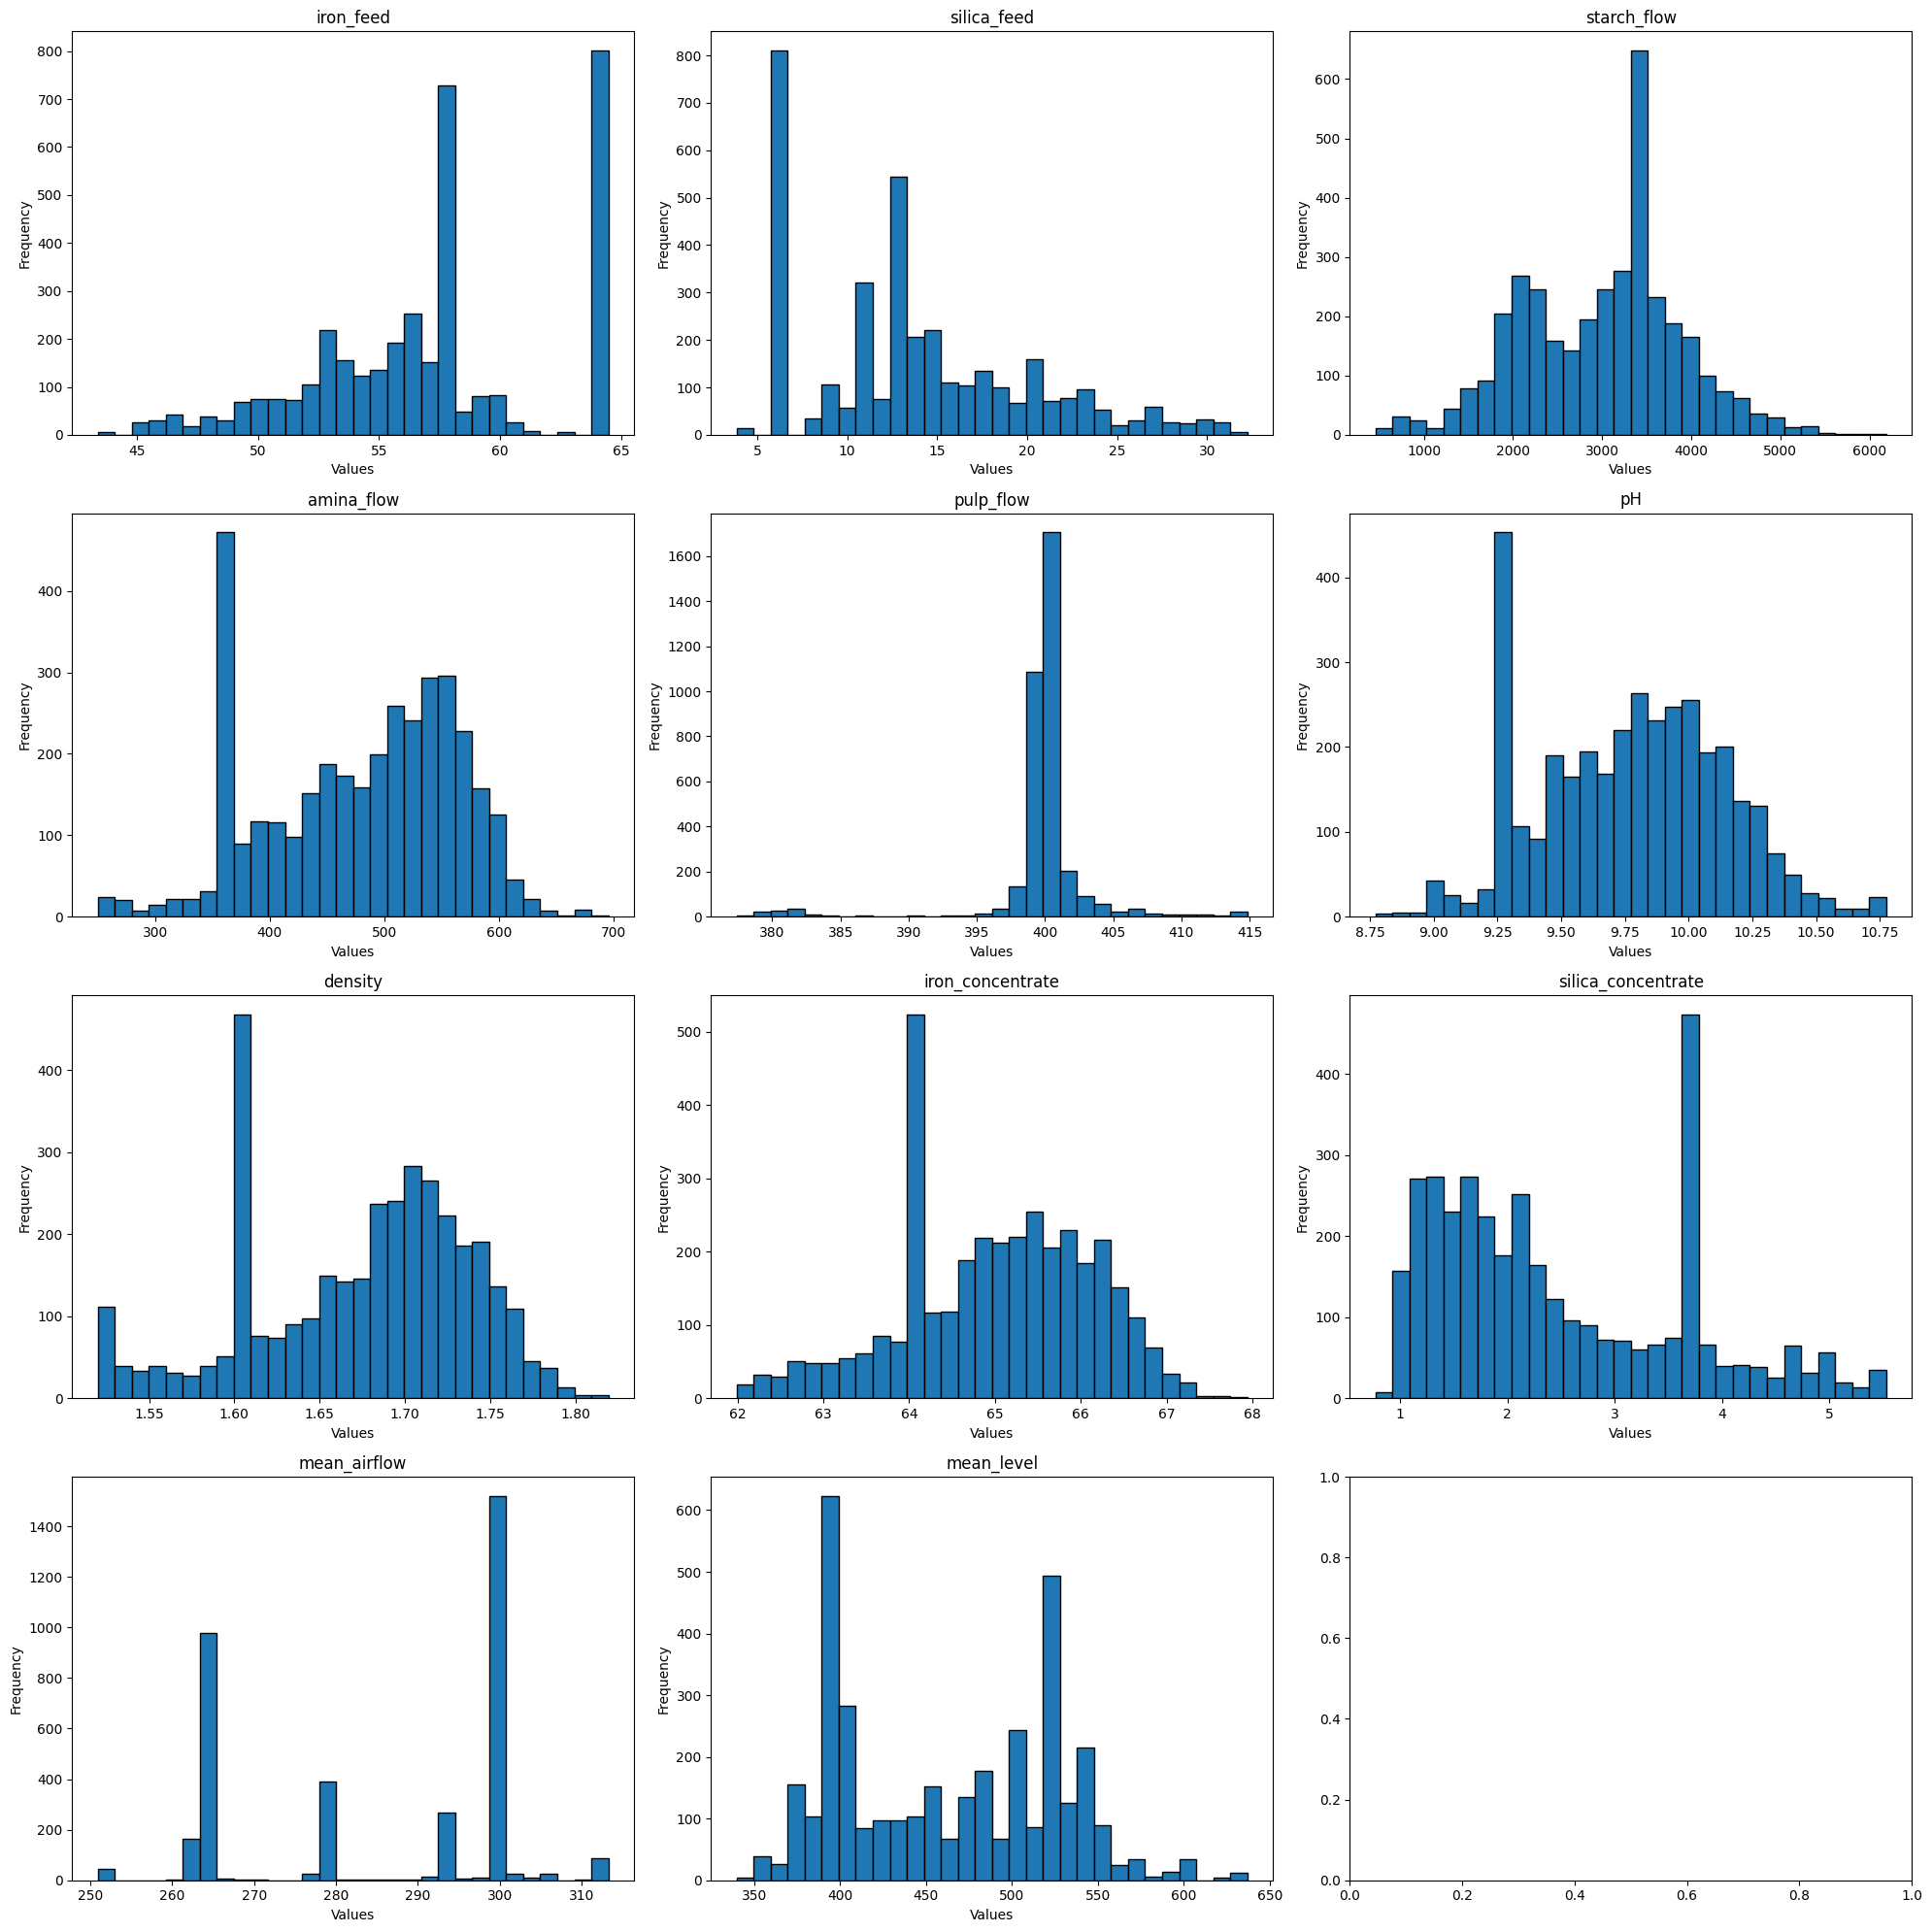

In [246]:
df = pd.read_csv("./cleaned_flotation_data_python.csv")

# Select only the input variables (columns 2 to 11)
input_variables = df.iloc[:, 1:12]

# Set a larger figure size for individual plots
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))

# Loop through each column and create a separate histogram plot
for idx, col in enumerate(input_variables.columns):
    ax = axs[idx // 3, idx % 3]  # Get the correct subplot axis
    input_variables[col].hist(ax=ax, bins=30, edgecolor='black', grid=False)
    ax.set_title(col)  # Set the title for each subplot
    ax.set_xlabel('Values')  # Set the x-axis label
    ax.set_ylabel('Frequency')  # Set the y-axis label

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


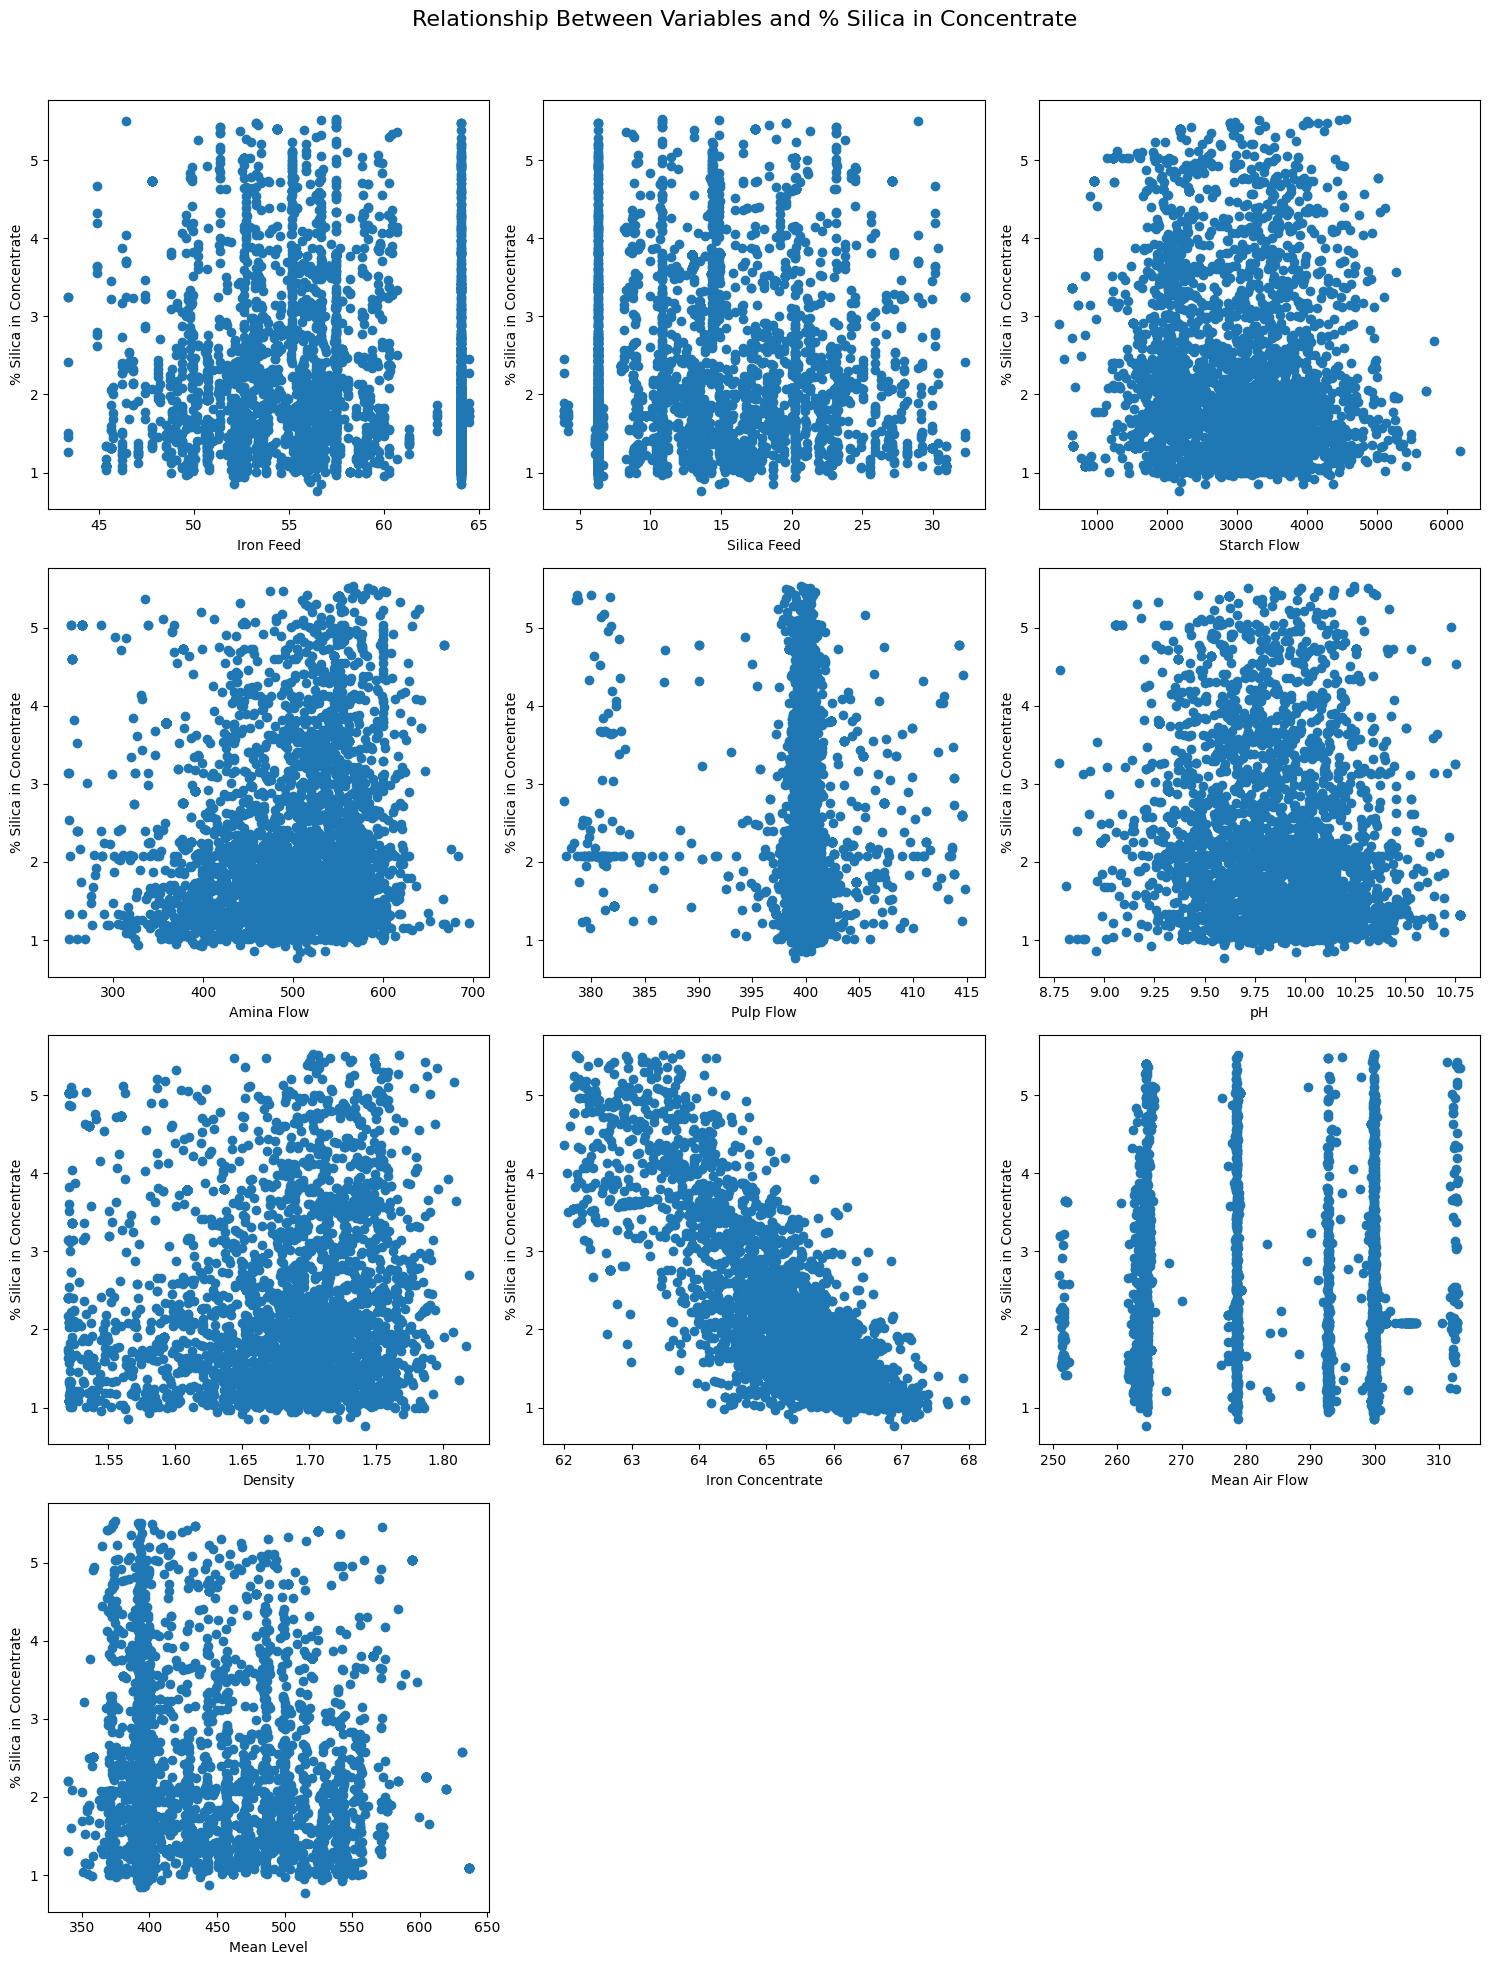

In [247]:
# Visualize the relationship between each variable and % silica in concentrate using scatter plots
plt.figure(figsize=(15, 20))

# Scatter plot for Iron Feed vs. % Silica in Concentrate
plt.subplot(4, 3, 1)
plt.scatter(df['iron_feed'], df['silica_concentrate'])
plt.xlabel('Iron Feed')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Silica Feed vs. % Silica in Concentrate
plt.subplot(4, 3, 2)
plt.scatter(df['silica_feed'], df['silica_concentrate'])
plt.xlabel('Silica Feed')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Starch Flow vs. % Silica in Concentrate
plt.subplot(4, 3, 3)
plt.scatter(df['starch_flow'], df['silica_concentrate'])
plt.xlabel('Starch Flow')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Amina Flow vs. % Silica in Concentrate
plt.subplot(4, 3, 4)
plt.scatter(df['amina_flow'], df['silica_concentrate'])
plt.xlabel('Amina Flow')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Pulp Flow vs. % Silica in Concentrate
plt.subplot(4, 3, 5)
plt.scatter(df['pulp_flow'], df['silica_concentrate'])
plt.xlabel('Pulp Flow')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for pH vs. % Silica in Concentrate
plt.subplot(4, 3, 6)
plt.scatter(df['pH'], df['silica_concentrate'])
plt.xlabel('pH')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Density vs. % Silica in Concentrate
plt.subplot(4, 3, 7)
plt.scatter(df['density'], df['silica_concentrate'])
plt.xlabel('Density')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Iron Concentrate vs. % Silica in Concentrate
plt.subplot(4, 3, 8)
plt.scatter(df['iron_concentrate'], df['silica_concentrate'])
plt.xlabel('Iron Concentrate')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Mean Air Flow vs. % Silica in Concentrate
plt.subplot(4, 3, 9)
plt.scatter(df['mean_airflow'], df['silica_concentrate'])
plt.xlabel('Mean Air Flow')
plt.ylabel('% Silica in Concentrate')

# Scatter plot for Mean Level vs. % Silica in Concentrate
plt.subplot(4, 3, 10)
plt.scatter(df['mean_level'], df['silica_concentrate'])
plt.xlabel('Mean Level')
plt.ylabel('% Silica in Concentrate')

# Add titles and adjust layout
plt.suptitle('Relationship Between Variables and % Silica in Concentrate', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to prevent overlap
plt.show()

It can easily be seen that silica concentration is independent of all the variables **except Iron Concentrate**.

# **TEST DATA**

In [248]:


# Load the scoring dataset
test_df = pd.read_csv("/content/scoringdataset.csv")

test_df.drop(test_df.columns[0], axis=1, inplace=True)

# Convert 'breaks' column to datetime format
test_df['breaks'] = pd.to_datetime(test_df['breaks'], format="%Y-%m-%d %H:%M:%S")

# Remove duplicates
test_df.drop_duplicates(inplace=True)



# Rename columns
test_df.columns = ['datehour', 'iron_feed', 'silica_feed', 'starch_flow',
                   'amina_flow', 'pulp_flow', 'pH', 'density',
                   'iron_concentrate', 'fc1_air_flow', 'fc2_air_flow',
                   'fc3_air_flow', 'fc4_air_flow', 'fc5_air_flow',
                   'fc6_air_flow', 'fc7_air_flow', 'fc1_level', 'fc2_level',
                   'fc3_level', 'fc4_level', 'fc5_level', 'fc6_level', 'fc7_level']
# Data validation - Apply boundary conditions
df = test_df[(test_df['amina_flow'].between(250, 700)) &
             (test_df['pulp_flow'].between(370, 415)) &
             (test_df['pH'].between(8.75, 10.8)) &
             (test_df['density'].between(1.5, 1.85)) &
             (test_df[['fc1_air_flow', 'fc2_air_flow', 'fc3_air_flow',
                       'fc4_air_flow', 'fc5_air_flow', 'fc6_air_flow',
                       'fc7_air_flow']].apply(lambda x: (x >= 220) & (x <= 350)).all(axis=1)) &
             (test_df[['fc1_level', 'fc2_level', 'fc3_level',
                       'fc4_level', 'fc5_level', 'fc6_level',
                       'fc7_level']].apply(lambda x: (x >= 150) & (x <= 750)).all(axis=1))]

# Calculate total airflow & total starch and amina flow
df['total_airflow'] = df[['fc1_air_flow', 'fc2_air_flow', 'fc3_air_flow',
                          'fc4_air_flow', 'fc5_air_flow', 'fc6_air_flow',
                          'fc7_air_flow']].sum(axis=1)

df['total_starch_amina'] = df[['starch_flow', 'amina_flow']].sum(axis=1)

# Filter out records with total starch and amina flow smaller than 1000
df = df[df['total_starch_amina'] >= 1000]

# Calculate mean air flow & mean level
df['mean_airflow'] = df[['fc1_air_flow', 'fc2_air_flow', 'fc3_air_flow',
                         'fc4_air_flow', 'fc5_air_flow', 'fc6_air_flow',
                         'fc7_air_flow']].mean(axis=1)

df['mean_level'] = df[['fc1_level', 'fc2_level', 'fc3_level',
                       'fc4_level', 'fc5_level', 'fc6_level',
                       'fc7_level']].mean(axis=1)

# Remove unnecessary columns
df.drop(columns=['fc1_air_flow', 'fc2_air_flow', 'fc3_air_flow',
                 'fc4_air_flow', 'fc5_air_flow', 'fc6_air_flow', 'fc7_air_flow',
                 'fc1_level', 'fc2_level', 'fc3_level', 'fc4_level',
                 'fc5_level', 'fc6_level', 'fc7_level', 'total_airflow',
                 'total_starch_amina'], inplace=True)

# Save the cleaned testing data to a new CSV file
df = df.fillna(method='ffill')
print(df.head())
df.to_csv("./cleaned_testing_data.csv", index=False)

             datehour  iron_feed  silica_feed  starch_flow  amina_flow  \
0 2017-08-06 20:00:00      54.43        17.29  2613.038169  454.561070   
1 2017-08-06 21:00:00      54.43        17.29  2521.177611  544.954628   
2 2017-08-06 22:00:00      54.43        17.29  3160.592611  533.799906   
3 2017-08-06 23:00:00      54.43        17.29  3217.510222  434.136239   
4 2017-08-07 00:00:00      54.43        17.29  2861.854944  474.722744   

    pulp_flow         pH   density  iron_concentrate  mean_airflow  mean_level  
0  378.064854   9.931762  1.686552         64.919704    285.657704  384.574803  
1  381.128578   9.800920  1.703249         65.084934    285.601711  414.887472  
2  394.198503   9.908214  1.694354         64.617513    285.547623  447.695269  
3  379.225582  10.176201  1.696288         65.161826    285.703989  457.508617  
4  380.136973   9.865055  1.704528         65.352088    285.646073  456.131109  


# **MODELLING**

In [249]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Load training data
df = pd.read_csv("./cleaned_flotation_data_python.csv")

# Drop the 'datehour' column
x_df = df.drop(columns=['date'])
print(x_df.head())
# Separate features (X) and target variable (y)
X = x_df.drop(columns=['silica_concentrate'])
X.head()
y = x_df['silica_concentrate']

# Impute missing values in X using the mean strategy
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)



   iron_feed  silica_feed  starch_flow  amina_flow   pulp_flow         pH  \
0       55.2        16.98  3178.782494  578.921220  398.729370  10.113374   
1       55.2        16.98  3133.256389  537.219661  399.871822  10.129742   
2       55.2        16.98  3477.949832  591.936682  398.669061  10.048187   
3       55.2        16.98  3263.574086  593.132045  399.832270   9.918717   
4       55.2        16.98  3361.650646  619.740017  399.620747   9.746565   

    density  iron_concentrate  silica_concentrate  mean_airflow  mean_level  
0  1.729785         66.896639                1.31    264.927111  452.561886  
1  1.667784         67.015997                1.11    264.490146  450.806422  
2  1.732812         66.914671                1.27    264.648900  452.052240  
3  1.731045         66.642603                1.36    264.553657  493.418282  
4  1.765887         66.605109                1.34    264.559945  551.292796  


# **LOGISTIC REGRESSION**

In [250]:

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, random_state=84,test_size=0.2)


#  LOGISTIC REGRESSION


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create and fit Linear Regression model
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

# Make predictions
y_pred_regression = regression_model.predict(X_test)

# Evaluate the model (e.g., using mean squared error)
mse = mean_squared_error(y_test, y_pred_regression)
print("Mean Squared Error (Linear Regression):", mse)


Mean Squared Error (Linear Regression): 0.4183576387213848


# RANDOM FOREST


In [251]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error


# Random Forest Regressor
rf = RandomForestRegressor(random_state=47)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest Regressor
mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Random Forest Mean Squared Error:", mse_rf)


Random Forest Mean Squared Error: 0.2748648537663537


# **K-Nearest Neighbors**

In [252]:

# K-Nearest Neighbors Regressor
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Evaluate K-Nearest Neighbors Regressor
mse_knn = mean_squared_error(y_test, y_pred_knn)
print("K-Nearest Neighbors Mean Squared Error:", mse_knn)

K-Nearest Neighbors Mean Squared Error: 1.04211402827427


# ERROR IS MINIMUM IN RANDOM FOREST MODEL

RandomForestRegressor(max_features='sqrt', random_state=47)


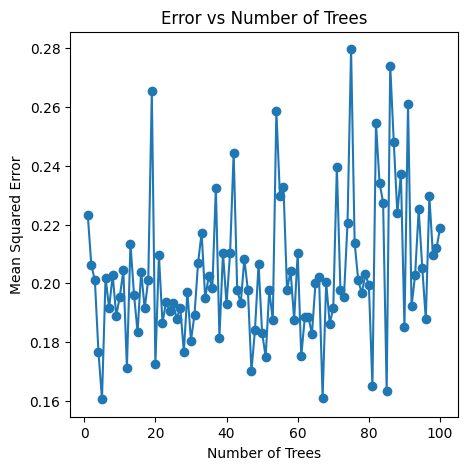

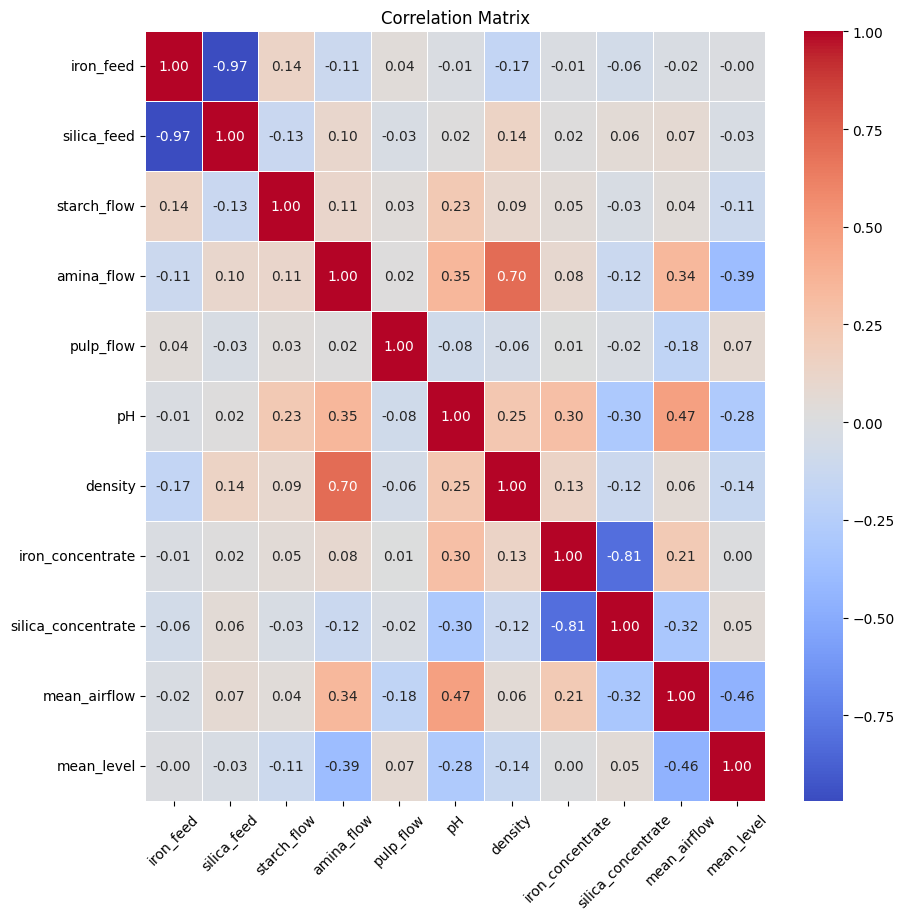

In [253]:

# Create random forest model
silica_rf = RandomForestRegressor(n_estimators=100, max_features='sqrt', random_state=47)
silica_rf.fit(X_imputed, y)

# Print model details
print(silica_rf)

# Plot the error vs the number of trees graph
plt.figure(figsize=(5, 5))
plt.plot(range(1, len(silica_rf.estimators_) + 1), [mean_squared_error(y, pred.predict(X_imputed)) for pred in silica_rf.estimators_], marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Mean Squared Error')
plt.title('Error vs Number of Trees')
plt.show()

# Plot correlation matrix of training dataset
corr = x_df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# **HYPERPARAMETER TUNING**

In [254]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
df = pd.read_csv("./cleaned_flotation_data_python.csv")

# Separate features (X) and target variable (y)
X = x_df
y = df['silica_concentrate']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Create random forest regressor model
rf_model = RandomForestRegressor(random_state=47)

# Create GridSearchCV object with the random forest model and parameter grid
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)

# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print("Best Hyperparameters:", grid_search.best_params_)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error on Test Set:", mse)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 150}
Mean Squared Error on Test Set: 0.008631977290240522


# **PREDICTION**

In [255]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Load test dataset
test = pd.read_csv("./cleaned_testing_data.csv")
test.head()
# Create a copy of the dataframe and exclude 'datehour' column
test_df = test.copy()
test_df = test_df.drop(columns=['datehour'])

# Use model to predict the silica %
preds = silica_rf.predict(test_df)

# Create a new dataframe with the predicted values and the original datehour column
results = pd.DataFrame({'datehour': test['datehour'], 'preds': preds})

# Save result for submission
results.to_csv('./Submission.csv', index=False)

### **THE END**